# 💰 Loan Amount Prediction

Regression task: predict the **loan amount** an applicant is likely to receive based on income, credit, and demographic features.

**Notebook outline:**
1. Imports & setup
2. Data loading & feature engineering
3. Feature & target selection
4. Preprocessing pipeline
5. Train/test split
6. Linear Regression baseline
7. Random Forest Regressor with GridSearch
8. Gradient Boosting Regressor
9. Model comparison & error analysis
10. Save best model

## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import *
from src.feature_engineering import *
from src.train import *
from src.evaluate import *
from src.utils import *

## 2. Data Loading & Feature Engineering

Load the enriched dataset and create all engineered features (`Total_Income`, `EMI_Income_Ratio`, `Loan_Income_Ratio`, etc.).

In [3]:
df = load_dataset("../dataset/hdfc_loan_dataset_full_enriched.csv")

df = basic_cleaning(df)

In [4]:
df = create_features(df)

## 3. Feature & Target Selection

Select predictors and set the continuous target `Loan_Amount`.

In [5]:
features = [
    "Applicant_Income",
    "Annual_Household_Income",
    "Asset_Value",
    "Existing_EMIs",
    "Employment_Length_Years",
    "CIBIL_Score",
    "Monthly_Expense",
    "Debt_to_Income_Ratio",
    "Occupation",
    "Property_Area",
    "Total_Income",
    "Loan_Income_Ratio",
    "EMI_Income_Ratio"
]

target = "Loan_Amount"

In [6]:
x, y = select_features(
    df,
    features,
    target
)

## 4. Preprocessing Pipeline

Build a `ColumnTransformer` for imputation, scaling, and encoding.

> Note: cell 7 re-runs `get_feature_types` to confirm the feature split after setup.

In [7]:
num_features, cat_features = get_feature_types(x)

In [8]:
preprocessor = create_preprocessor(
    num_features,
    cat_features
)

## 5. Train / Test Split

Split data 80/20 (random_state=42).

In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

## 6. Linear Regression (Baseline)

Fit a simple linear regression to establish a performance baseline.

In [10]:
lr_pipeline = build_pipeline(
    preprocessor,
    LinearRegression()
)

In [11]:
lr_pipeline.fit(
    x_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
lr_pred = predict(
    lr_pipeline,
    x_test
)

In [13]:
lr_results = evaluate_regression(
    y_test,
    lr_pred
)
lr_results

,MAE,MSE,RMSE,R2 Score
0,1.961645e+06,6.276033e+12,2.505201e+06,-0.034152


## 7. Random Forest Regressor with GridSearchCV

Tune `n_estimators` and `max_depth` via grid search to find the optimal Random Forest regressor.

In [14]:
rf_pipeline = build_pipeline(

    preprocessor,

    RandomForestRegressor(
        random_state=42
    )

)

In [15]:
rf_params = {
    "classifier__n_estimators":[100,200],
    "classifier__max_depth":[5,10,15],
    "classifier__min_samples_split":[2,5],
    "classifier__min_samples_leaf":[1,2]
}

In [16]:
grid_rf = perform_grid_search(
    rf_pipeline,
    rf_params,
    x_train,
    y_train,
    scoring="r2"
)

In [17]:
rf_best_model = grid_rf.best_estimator_

In [18]:
rf_pred = predict(
    rf_best_model,
    x_test
)

In [19]:
rf_results = evaluate_regression(
    y_test,
    rf_pred
)
rf_results

,MAE,MSE,RMSE,R2 Score
0,233922.040749,2.810685e+11,530158.961032,0.953686


## 8. Gradient Boosting Regressor

Train a `GradientBoostingRegressor` and compare with the Random Forest.

In [20]:
gb_pipeline = build_pipeline(
    preprocessor,
    GradientBoostingRegressor(
        random_state=42
    )
)

In [21]:
gb_pipeline.fit(
    x_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
gb_pred = predict(
    gb_pipeline,
    x_test
)

In [23]:
gb_results = evaluate_regression(
    y_test,
    gb_pred
)
gb_results

,MAE,MSE,RMSE,R2 Score
0,293134.577539,2.573535e+11,507300.203629,0.957594


## 9. Model Comparison & Error Analysis

Compare MAE, MSE, RMSE, and R² across all three models. Visualise residuals and actual-vs-predicted scatter plots.

In [24]:
comparison = compare_models(
    [lr_results, rf_results, gb_results],
    names=["Linear Regression", "Random Forest", "Gradient Boosting"]
)
comparison

,MAE,MSE,RMSE,R2 Score
Linear Regression,1.961645e+06,6.276033e+12,2.505201e+06,-0.034152
Random Forest,2.339220e+05,2.810685e+11,5.301590e+05,0.953686
Gradient Boosting,2.931346e+05,2.573535e+11,5.073002e+05,0.957594


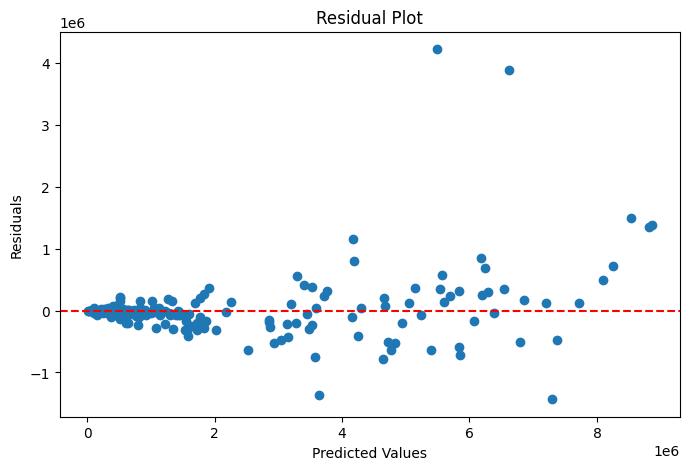

In [25]:
residual_plot(
    y_test,
    rf_pred
)

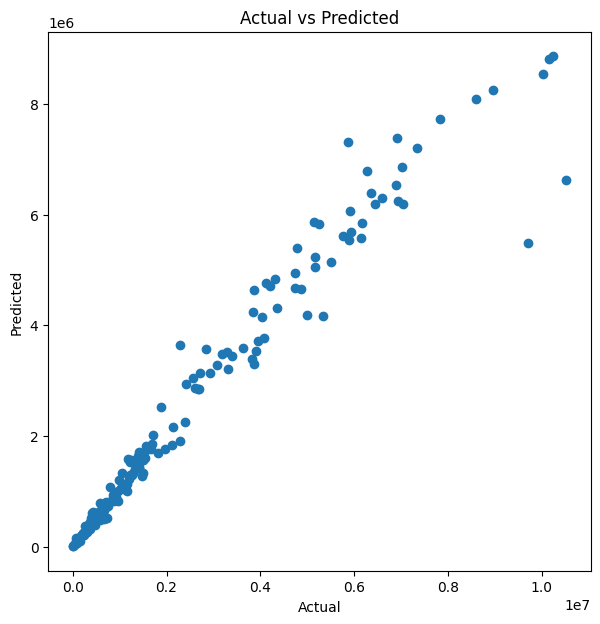

In [26]:
actual_vs_predicted(
    y_test,
    rf_pred
)

In [27]:
best_rf = grid_rf.best_estimator_

## 10. Save Best Model

Persist the best model to `models/loan_amount_model.pkl` with `joblib`.

In [28]:
save_model(best_rf, "../models/loan_amount_model.pkl")

Model saved → ../models/loan_amount_model.pkl
